In [4]:
import ee
ee.Initialize()

In [1]:
import geopandas as gpd

mal_2015 = gpd.read_file("./exports/malaria_2015_selected.csv")
mal_2020 = gpd.read_file("./exports/malaria_2015_selected.csv")

In [ ]:
import ee
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

def sample_dynamic_world_lulc(df, start_date='2015-01-01', end_date='2016-01-01', lon_col='longitude', lat_col='latitude'):
    """
    Samples Dynamic World LULC values for a set of points provided in a DataFrame.

    Parameters:
        df (pd.DataFrame or gpd.GeoDataFrame): DataFrame with point coordinates.
        start_date (str): Start date of the image collection filter.
        end_date (str): End date of the image collection filter.
        lon_col (str): Name of the longitude column.
        lat_col (str): Name of the latitude column.

    Returns:
        pd.DataFrame: DataFrame with LULC values sampled from Dynamic World.
    """


    # Convert DataFrame to GeoDataFrame if necessary
    if not isinstance(df, gpd.GeoDataFrame):
        geometry = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
        gdf = gpd.GeoDataFrame(df.copy(), geometry=geometry, crs='EPSG:4326')
    else:
        gdf = df.to_crs('EPSG:4326')

    # Create EE FeatureCollection from GeoDataFrame
    features = []
    for _, row in gdf.iterrows():
        geom = ee.Geometry.Point(row.geometry.x, row.geometry.y)
        feature = ee.Feature(geom, row.drop('geometry').to_dict())
        features.append(feature)
    ee_fc = ee.FeatureCollection(features)

    # Create the Dynamic World mean image
    bbox = ee_fc.geometry().bounds()
    dw_image = (ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
                .filterDate(start_date, end_date)
                .filterBounds(bbox)
                .select('label')
                .mean()
                .clip(bbox))

    # Sample the image at the feature points
    sampled = dw_image.sampleRegions(collection=ee_fc, scale=10, geometries=True)

    # Get results to client
    sampled_dict = sampled.getInfo()

    # Convert to pandas DataFrame
    records = []
    for feat in sampled_dict['features']:
        props = feat['properties']
        geom = feat['geometry']['coordinates']
        props['longitude'] = geom[0]
        props['latitude'] = geom[1]
        records.append(props)

    return pd.DataFrame(records)


In [6]:
mal_2015[['LATNUM', 'LONGNUM']]

,LATNUM,LONGNUM
0,-1.270583,36.963737
1,-0.385871,37.109734
2,-0.566701,37.046412
3,-0.476565,37.141745
4,-0.424037,36.936094
...,...,...
215,0.579619,34.372331
216,0.616486,34.250503
217,0.54432,34.236645
218,0.625001,34.28438


In [14]:
lulc_2015 = sample_dynamic_world_lulc(mal_2015, start_date='2015-01-01', end_date='2016-01-01', lon_col='LONGNUM', lat_col='LATNUM')
lulc_2015.rename(columns={'label': 'LULC_2015'}, inplace=True)

In [15]:
# LULC_2020
lulc_2020 = sample_dynamic_world_lulc(mal_2020, start_date='2020-01-01', end_date='2021-01-01', lon_col='LONGNUM', lat_col='LATNUM')
lulc_2020.rename(columns={'label': 'LULC_2020'}, inplace=True)

<Axes: >

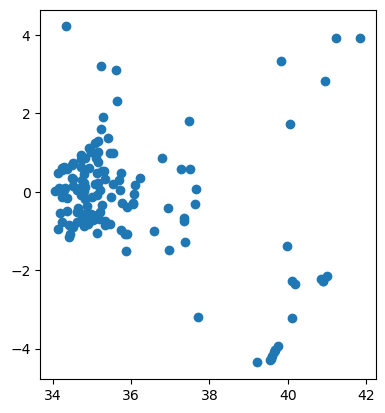

In [18]:
gpd.GeoDataFrame(lulc_2015, geometry=gpd.points_from_xy(lulc_2015['longitude'], lulc_2015['latitude'])).plot()

In [19]:
import rasterio
from rasterio.sample import sample_gen
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

def extract_raster_values(raster_path, df, lon_col='longitude', lat_col='latitude', band=1, new_col='raster_val'):
    """
    Extracts values from a raster file at point locations and adds them to the DataFrame.

    Parameters:
        raster_path (str): Path to the raster file (GeoTIFF).
        df (pd.DataFrame): DataFrame with lat/lon columns.
        lon_col (str): Name of longitude column.
        lat_col (str): Name of latitude column.
        band (int): Raster band to sample from (default is 1).
        new_col (str): Name of the new column to store raster values.

    Returns:
        pd.DataFrame: DataFrame with raster values added.
    """
    # Convert to GeoDataFrame with geometry
    gdf = gpd.GeoDataFrame(df.copy(), 
                           geometry=gpd.points_from_xy(df[lon_col], df[lat_col]), 
                           crs='EPSG:4326')

    with rasterio.open(raster_path) as src:
        # Reproject to match raster CRS
        gdf = gdf.to_crs(src.crs)

        # Get coordinates to sample
        coords = [(geom.x, geom.y) for geom in gdf.geometry]

        # Sample the raster
        values = [val[0] if val else None for val in src.sample(coords, indexes=band)]

        # Add to DataFrame
        gdf[new_col] = values

    return pd.DataFrame(gdf.drop(columns='geometry'))


In [22]:
path_to_raster = "C:/Users/roywaswa/Downloads/Euclid_rivers.tif"
raster_2015 = extract_raster_values(path_to_raster, lulc_2015, lon_col='longitude', lat_col='latitude', band=1, new_col='dist_water')
raster_2020 = extract_raster_values(path_to_raster, lulc_2020, lon_col='longitude', lat_col='latitude', band=1, new_col='dist_water')

In [24]:
raster_2020.to_csv("./exports/new_data_2020.csv")
raster_2015.to_csv("./exports/new_data_2015.csv")